# AirQuality-Lib
This notebook demonstrates a workflow implemented by airqualitylib:
1. Load hourly air-quality NetCDF data, landcover NetCDF data and country boundary
2. Clip to AOI
3. Aggregate to monthly mean
4. Align and reclass land-cover to the air-quality grid
5. Compute land-cover–stratified statistics (zonal-style summary)
6. Export a CSV table and generate diagnostic plots

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

from airqualitylib.geospatial_airquality import (
    load_air_quality,
    load_admin_boundaries,
    get_admin_boundary,
    ensure_crs,
    clip_to_aoi,
    monthly_mean,
    load_landcover,
    align_categorical_to_reference,
    reclass_landcover,
    overlay_aq_with_landcover,
    landcover_stats,
    LANDCOVER_6_LABELS,
    get_landcover_6_colormap,
    plot_monthly_map_with_landcover_overlay,
    plot_landcover_stats,
    export_landcover_tif,
    hello,
 )

print(hello())
print({
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "xarray": xr.__version__,
    "geopandas": gpd.__version__,
})

Hello, AirQualityLib
{'numpy': '2.3.5', 'pandas': '2.3.3', 'xarray': '2025.12.0', 'geopandas': '1.1.1'}


## 1. Load data

In [ ]:
DATA_DIR = Path("example_data")
NO2_PATH = DATA_DIR / "cams.eaq.vra.ENSa.no2.l0.2022-02.nc"
BOUNDARIES_PATH = DATA_DIR / "EU_countryboundaries.gpkg"
LANDCOVER_PATH = DATA_DIR / "C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.area-subset.72.45.30.-25.nc"

assert NO2_PATH.exists(), f"Missing: {NO2_PATH}"
assert BOUNDARIES_PATH.exists(), f"Missing: {BOUNDARIES_PATH}"
assert LANDCOVER_PATH.exists(), f"Missing: {LANDCOVER_PATH}"

NO2_PATH, BOUNDARIES_PATH, LANDCOVER_PATH

(WindowsPath('example_data/cams.eaq.vra.ENSa.no2.l0.2022-02.nc'),
 WindowsPath('example_data/EU_countryboundaries.gpkg'),
 WindowsPath('example_data/C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.area-subset.72.45.30.-25.nc'))

## 2. Clip to AOI

In [ ]:
aq = load_air_quality(str(NO2_PATH))
print(aq)

try:
    aoi = get_admin_boundary("Italy", by="NAME", path=str(BOUNDARIES_PATH))
except Exception:
    gdf = load_admin_boundaries(path=str(BOUNDARIES_PATH))
    from shapely.geometry import box
    lon_min = float(aq.lon.min())
    lon_max = float(aq.lon.max())
    lat_min = float(aq.lat.min())
    lat_max = float(aq.lat.max())
    bbox = box(lon_min, lat_min, lon_max, lat_max)
    intersecting = gdf[gdf.geometry.intersects(bbox)]
    aoi = intersecting.iloc[[0]] if len(intersecting) > 0 else gdf.iloc[[0]]

aoi = ensure_crs(aoi, epsg=4326)
aoi.head(1)

<xarray.DataArray 'no2' (time: 672, lat: 420, lon: 700)> Size: 790MB
[197568000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 5kB 2022-02-01 ... 2022-02-28T23:00:00
  * lat      (lat) float64 3kB 30.05 30.15 30.25 30.35 ... 71.75 71.85 71.95
  * lon      (lon) float64 6kB -24.95 -24.85 -24.75 -24.65 ... 44.75 44.85 44.95
Attributes:
    standard_name:  mass_concentration_of_nitrogen_dioxide_in_air
    long_name:      mass concentration of nitrogen dioxide
    units:          µg/m3
    cell_methods:   Time: mean
    source:         mass concentration of nitrogen dioxide at 0 meters above ...


,iso_a2,NAME,FIPS_10_,ISO_A3,WB_A2,WB_A3,Group,geometry
8,IT,Italy,IT,ITA,IT,ITA,6,"MULTIPOLYGON (((12.61109 35.48924, 12.52613 35..."


## 3. Aggregate to monthly mean

In [ ]:
aq_feb = monthly_mean(aq, month="2022-02", time_dim="time")

aq_feb_clipped = clip_to_aoi(aq_feb, aoi)
aq_feb_clipped

<xarray.DataArray 'no2' (lat: 117, lon: 120)> Size: 56kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(117, 120), dtype=float32)
Coordinates:
  * lat          (lat) float64 936B 47.05 46.95 46.85 ... 35.65 35.55 35.45
  * lon          (lon) float64 960B 6.65 6.75 6.85 6.95 ... 18.35 18.45 18.55
    spatial_ref  int64 8B 0
Attributes:
    standard_name:  mass_concentration_of_nitrogen_dioxide_in_air
    long_name:      mass concentration of nitrogen dioxide
    units:          µg/m3
    cell_methods:   Time: mean
    source:         mass concentration of nitrogen dioxide at 0 meters above ...

## 4. Align and reclass land-cover to the air-quality grid

In [ ]:
lc_raw = load_landcover(str(LANDCOVER_PATH), var="lccs_class")
aq2d, lc6_on_aq = overlay_aq_with_landcover(aq_feb_clipped, lc_raw, reclass=True, mask_by_aq=True)
aq2d, lc6_on_aq

(<xarray.DataArray 'no2' (lat: 117, lon: 120)> Size: 56kB
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(117, 120), dtype=float32)
 Coordinates:
   * lat          (lat) float64 936B 47.05 46.95 46.85 ... 35.65 35.55 35.45
   * lon          (lon) float64 960B 6.65 6.75 6.85 6.95 ... 18.35 18.45 18.55
     spatial_ref  int64 8B 0
 Attributes:
     standard_name:  mass_concentration_of_nitrogen_dioxide_in_air
     long_name:      mass concentration of nitrogen dioxide
     units:          µg/m3
     cell_methods:   Time: mean
     source:         mass concentration of nitrogen dioxide at 0 meters above ...,
 <xarray.DataArray 'landcover_6' (lat: 117, lon: 120)> Size: 56kB
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..

## 5. Compute land-cover–stratified statistics (zonal-style summary)

In [ ]:
df_stats = landcover_stats(aq2d, lc6_on_aq, threshold=40.0, class_labels=LANDCOVER_6_LABELS)
df_stats

,class,label,n_pixels,pixel_ratio,mean,exceed_ratio,max,median
0,1,Agriculture,1783,0.468840,13.425550,0.000000,39.980152,10.504710
1,2,Forest,1020,0.268209,9.640123,0.000000,37.400299,8.456142
2,3,Grassland,228,0.059953,6.598806,0.000000,24.807440,5.488125
3,4,Wetland,4,0.001052,13.020957,0.000000,21.166605,13.051639
4,5,Settlement,140,0.036813,21.932844,0.042857,45.902344,22.099380
5,6,Other,628,0.165133,8.562556,0.000000,37.194145,6.113138


## 6. Export a CSV table and generate diagnostic plots

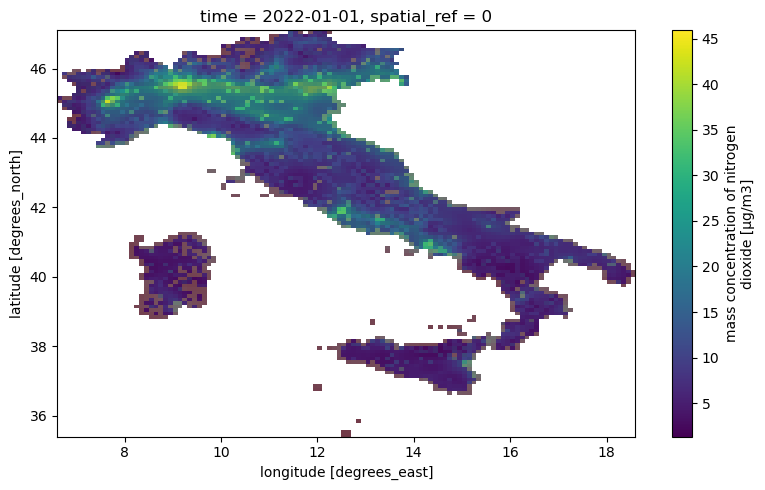

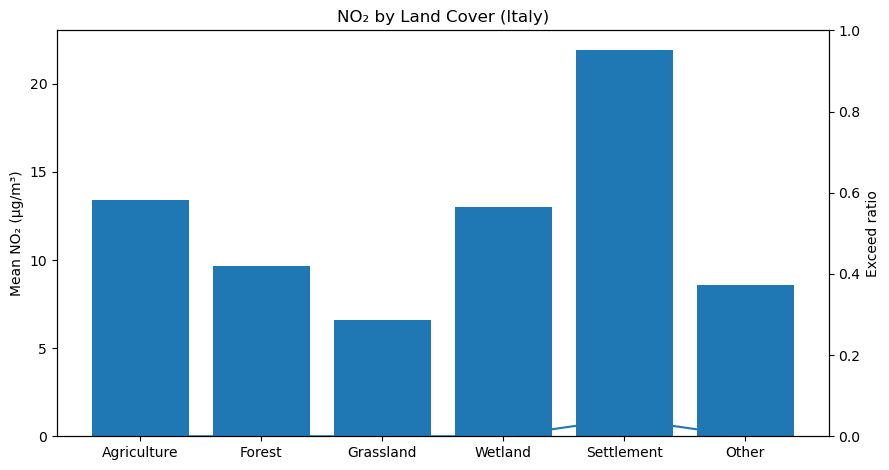

Exported: outputs_smoke\landcover_on_aq.tif


(WindowsPath('outputs_smoke/aq_landcover_overlay.png'),
 WindowsPath('outputs_smoke/landcover_stats.png'),
 WindowsPath('outputs_smoke/landcover_on_aq.tif'))

In [ ]:
OUT_DIR = Path("outputs_smoke")
OUT_DIR.mkdir(exist_ok=True)

map_png = OUT_DIR / "aq_landcover_overlay.png"
stats_png = OUT_DIR / "landcover_stats.png"
tif_path = OUT_DIR / "landcover_on_aq.tif"

plot_monthly_map_with_landcover_overlay(aq2d, lc6_on_aq, title="NO₂ Monthly Mean (Italy)", savepath=str(map_png))
plot_landcover_stats(df_stats, title="NO₂ by Land Cover (Italy)", savepath=str(stats_png))

try:
    export_landcover_tif(lc6_on_aq, str(tif_path))
    print("Exported:", tif_path)
except Exception as e:
    print("GeoTIFF export skipped:", e)

map_png, stats_png, tif_path

In [ ]:
csv_path = OUT_DIR / "landcover_stats.csv"
df_stats.to_csv(csv_path, index=False)
csv_path

WindowsPath('outputs_smoke/landcover_stats.csv')